# EXPLORATORY DATA ANALYSIS

### IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

### LOADING DATASET

In [2]:
df = pd.read_csv(r"C:\Users\RICHA DESAI\Downloads\superstore.csv")

### Q1. Data Cleaning

In [3]:
# Q1.i. Counting and Handling Missing values

In [4]:
missing = df.isnull().sum()
print(missing)

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     5
State             3
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64


In [6]:
df["Shipping.Cost"].fillna(df["Shipping.Cost"].median(), inplace = True)

In [7]:
df["State"].fillna(df["State"].mode()[0], inplace = True)

In [8]:
# Q1.ii. Dealing with Duplicate Values

In [9]:
duplicates = df.duplicated().sum()
print (("Duplicates:"), duplicates)

Duplicates: 0


In [10]:
# Q1.iii. Removing Unknown Columns

In [11]:
df['记录数'].value_counts()

记录数
1    51290
Name: count, dtype: int64

In [12]:
df.drop(columns = ['记录数'], inplace = True)

In [13]:
# Q1.iv. Checking Shape, Size & Data Types

In [16]:
shape = df.shape
print (("Shape:"),shape)

Shape: (51290, 26)


In [17]:
size = df.size
print (("Size:"), size)

Size: 1333540


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   Order.Date      51290 non-null  object 
 8   Order.ID        51290 non-null  object 
 9   Order.Priority  51290 non-null  object 
 10  Product.ID      51290 non-null  object 
 11  Product.Name    51290 non-null  object 
 12  Profit          51290 non-null  float64
 13  Quantity        51290 non-null  int64  
 14  Region          51290 non-null  object 
 15  Row.ID          51290 non-null  int64  
 16  Sales           51290 non-null  int64  
 17  Segment         51290 non-null 

### Q2. Performing Univariate Analysis accross all Numerical Variables

In [20]:
num_cols = ['Discount', 'Profit', 'Quantity', 'Sales', 'Shipping.Cost', 'Year', 'weeknum']

In [22]:
num_summary = df[num_cols].describe().T
display(num_summary)

,count,mean,std,min,25%,50%,75%,max
Discount,51290.0,0.142908,0.212280,0.000,0.00,0.00,0.20,0.850
Profit,51290.0,28.610982,174.340972,-6599.978,0.00,9.24,36.81,8399.976
Quantity,51290.0,3.476545,2.278766,1.000,2.00,3.00,5.00,14.000
Sales,51290.0,246.498440,487.567175,0.000,31.00,85.00,251.00,22638.000
Shipping.Cost,51290.0,26.376250,57.296646,0.002,2.61,7.79,24.45,933.570
Year,51290.0,2012.777208,1.098931,2011.000,2012.00,2013.00,2014.00,2014.000
weeknum,51290.0,31.287112,14.429795,1.000,20.00,33.00,44.00,53.000


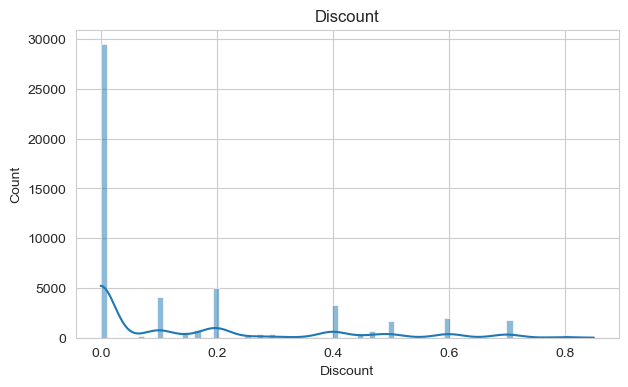

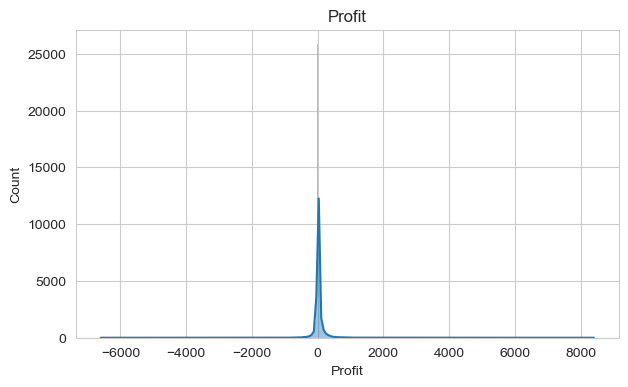

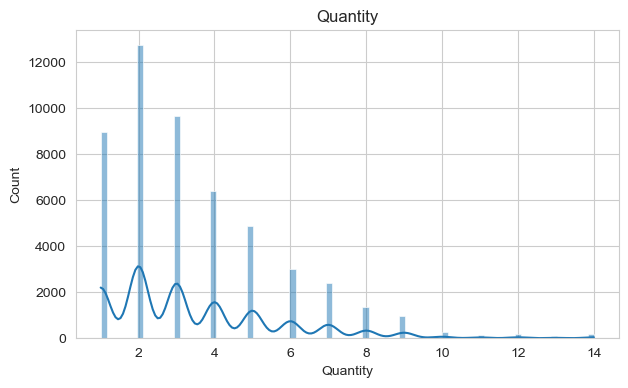

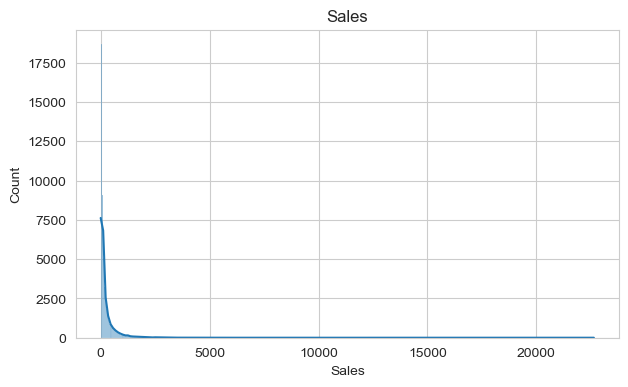

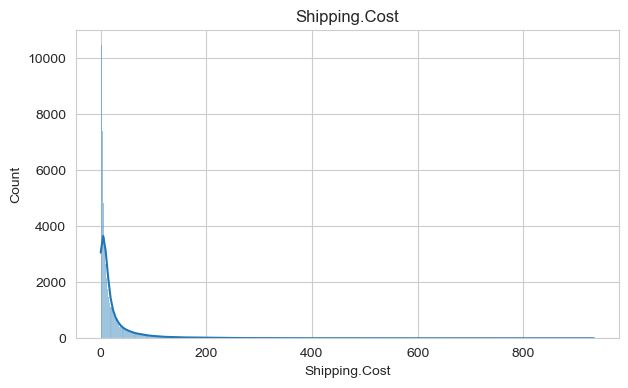

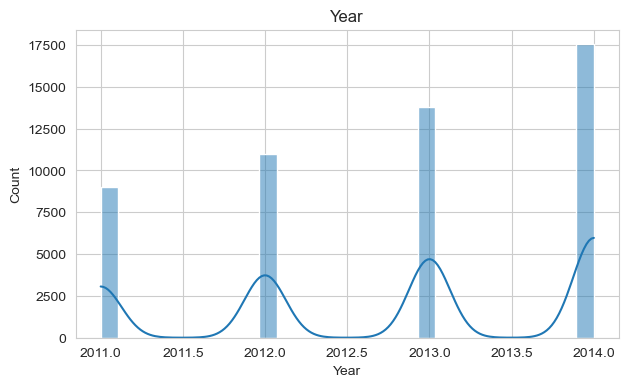

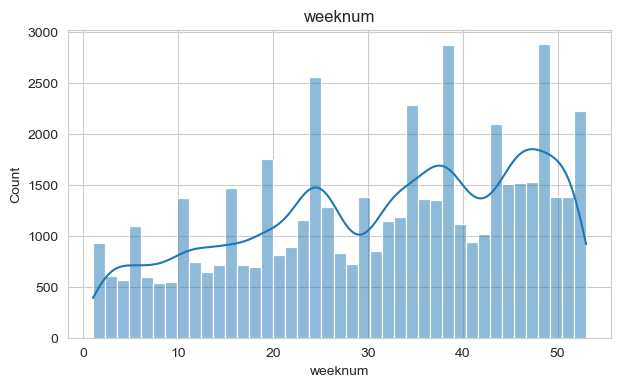

In [84]:
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde = True)
    plt.title(col)
    plt.show()

In [23]:
# Q2.i. Which features seem useless in the analysis? Explain why? 

In [24]:
# Q2.ii. Which features are uniformly distributed or normally distributed?

In [ ]:
# Q3.iii. Which features are right-skewed/left-skewed? What does this signify? 

In [25]:
df[num_cols].skew()

Discount         1.387775
Profit           4.157189
Quantity         1.360368
Sales            8.137981
Shipping.Cost    5.863256
Year            -0.344515
weeknum         -0.342451
dtype: float64

In [ ]:
# Q2.iv. Which features have a high number of outliers, and discuss the impact. 

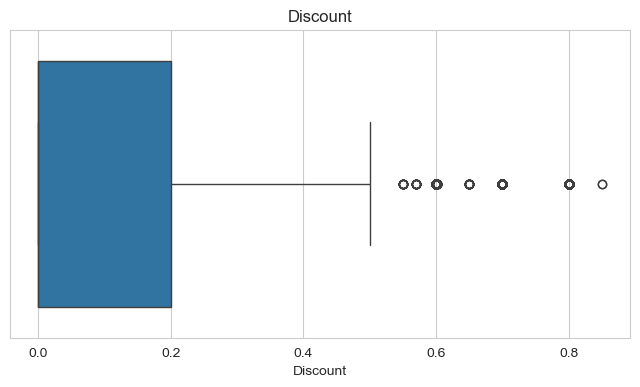

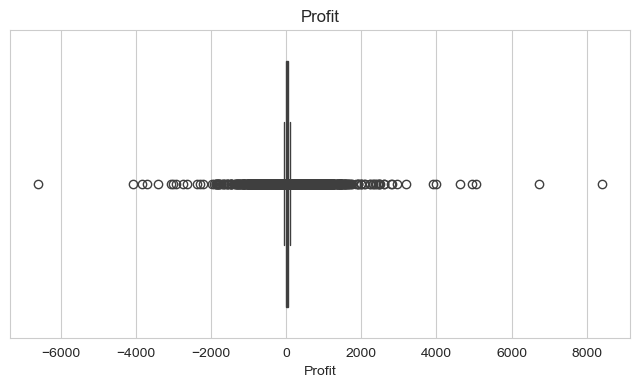

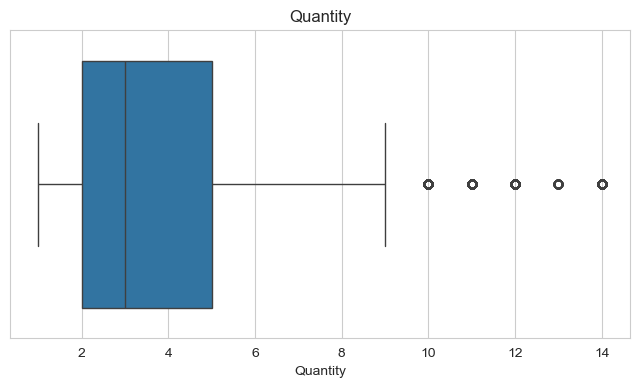

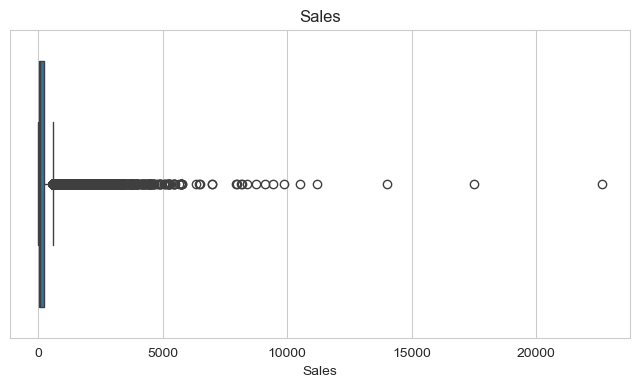

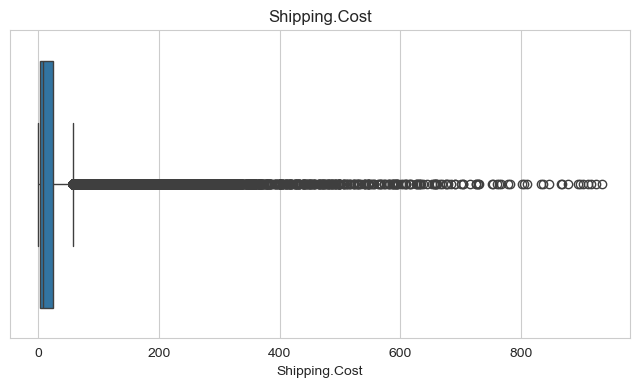

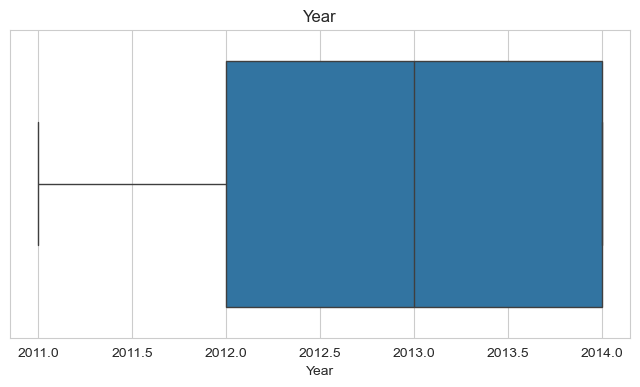

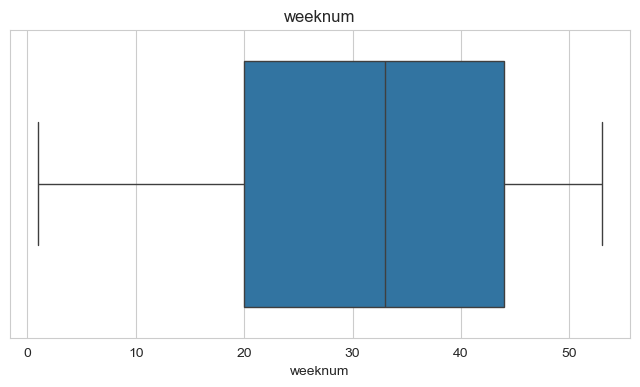

In [26]:
for col in num_cols:
    plt.figure(figsize = (8,4))
    sns.boxplot(x = df[col])
    plt.title(col)
    plt.show()

### Q3: Perform Univariate Analysis across all categorical features. 

In [33]:
cat_cols = ['Category', 'City', 'Country', 'Market', 'Order.Priority', 'Region', 'Segment', 'Ship.Mode', 'State', 'Sub.Category', 'Market2']

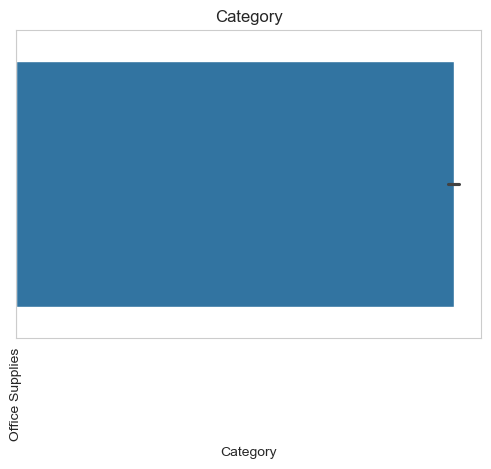

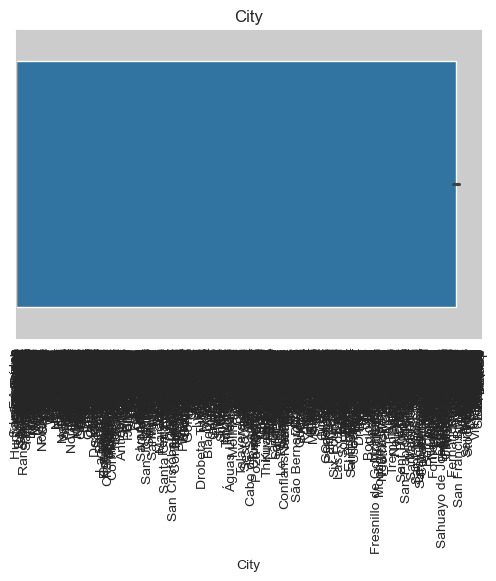

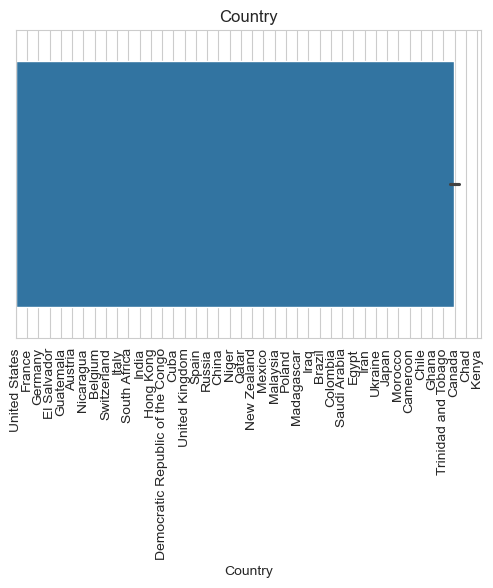

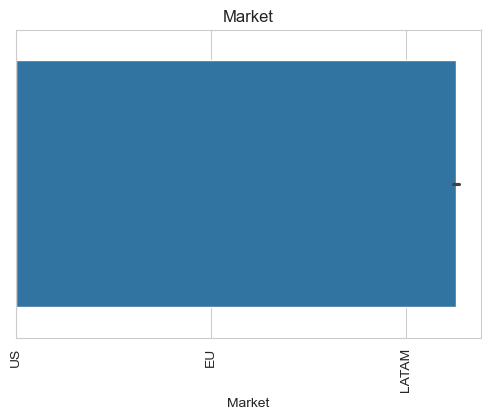

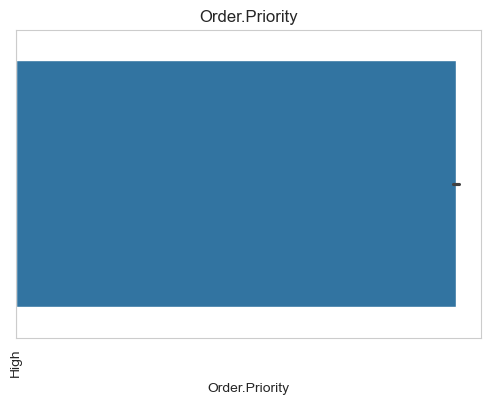

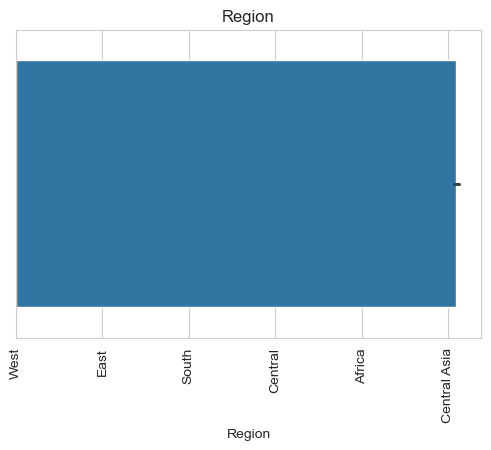

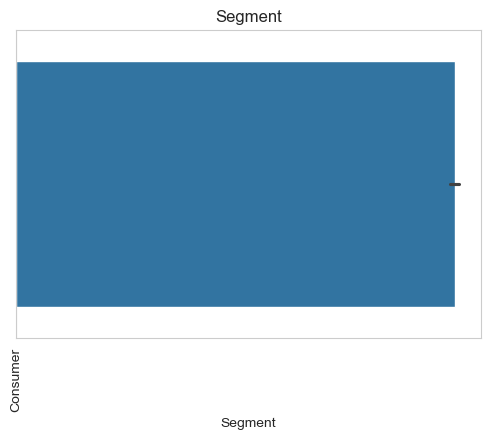

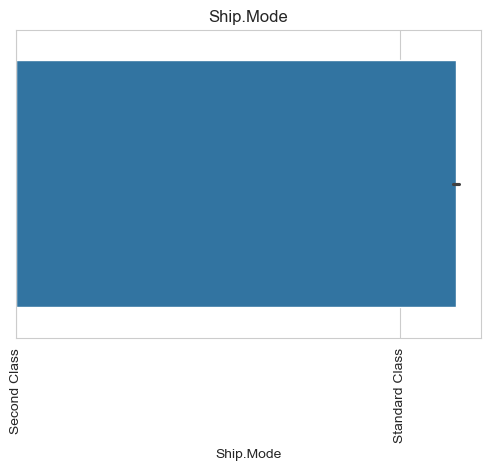

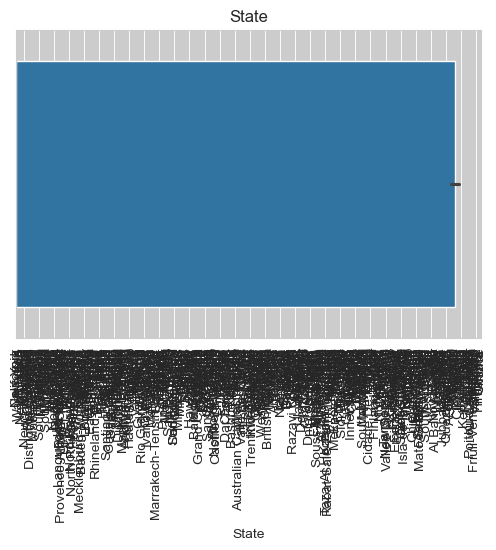

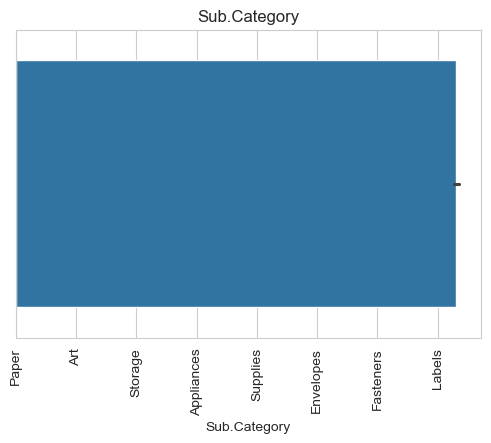

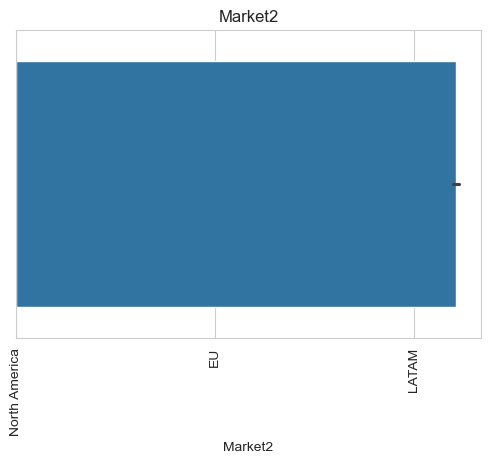

In [85]:
for col in cat_cols:
    plt.figure(figsize = (6,4))
    sns.barplot(x = df[col])
    plt.title(col)
    plt.xticks(rotation = 90)
    plt.show()

In [36]:
# Q3.i. Which features seem inaccurate and are not useful as categorical “insights” directly?

In [37]:
# Q3.ii. What’s the issue with treating Customer Name as a categorical feature for modeling?

In [38]:
# Q3.iii. Is the Category distribution balanced or skewed?

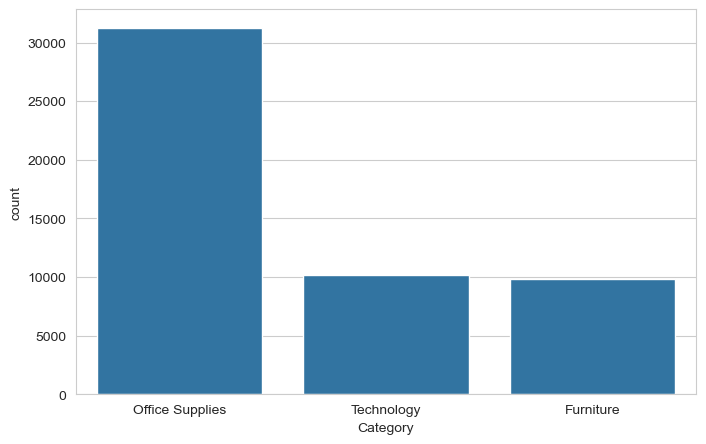

Category
Office Supplies    60.972899
Technology         19.771885
Furniture          19.255215
Name: proportion, dtype: float64


In [39]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Category')
plt.show()

print(df['Category'].value_counts(normalize=True)*100)

In [40]:
# Q3.iv. In Country, does one country dominate strongly? What does that imply about geographic bias?

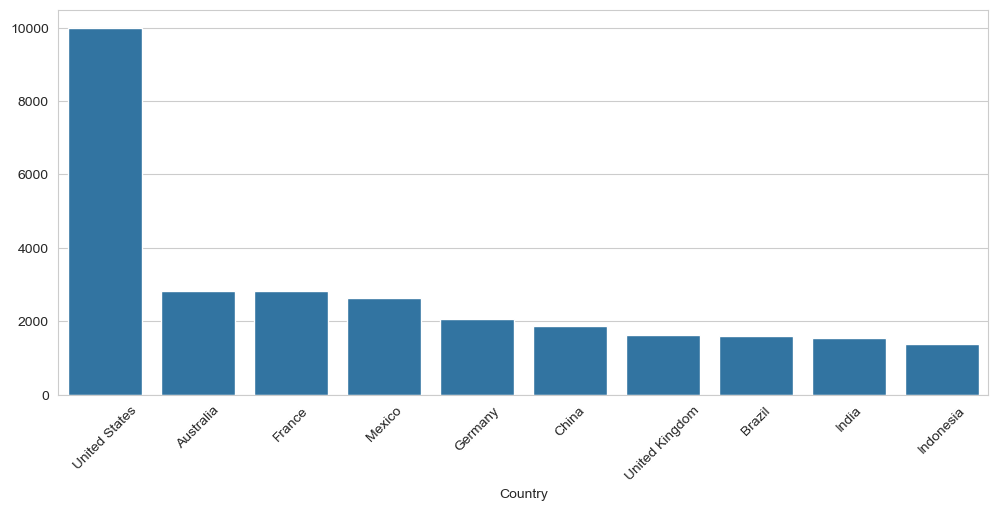

In [41]:
top_country = df['Country'].value_counts().head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_country.index,y=top_country.values)
plt.xticks(rotation=45)
plt.show()

In [42]:
# Q3.v. Is the City dataset concentrated in a few cities or spread out? 

In [46]:
Total_Cities = df['City'].nunique()
print (("Total Cities are:"), Total_Cities)

Total Cities are: 3636


### Q4. Perform Bivariant Analysis for numerical-to-numerical features.

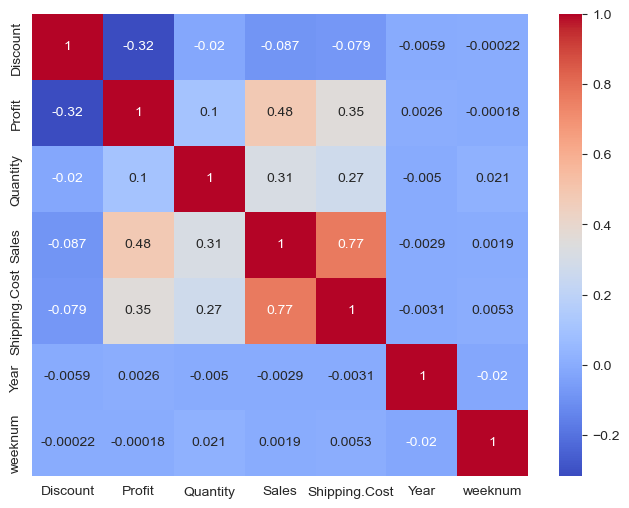

In [48]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [49]:
# Q4.i. Which two features are most strongly correlated?

In [ ]:
# Q4. ii. Name the features that are negatively correlated.

In [ ]:
# Q4. iii. If your goal is to understand profit, which are the most useful next bivariate checks? Perform them and give clear insights. 

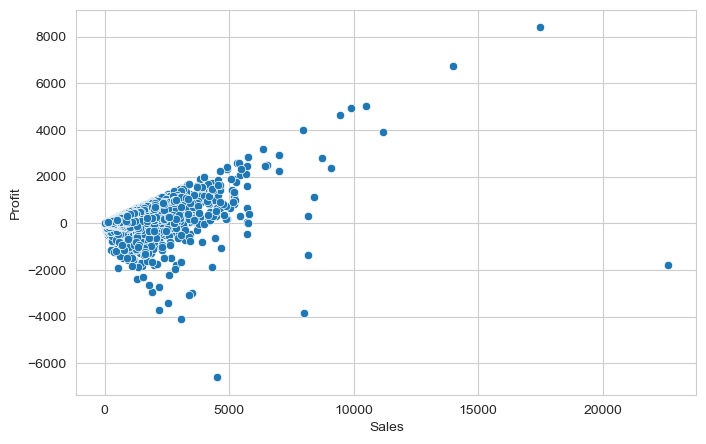

In [51]:
# Profit vs Sales
plt.figure(figsize=(8,5))
sns.scatterplot(x = 'Sales', y = 'Profit', data = df)
plt.show()

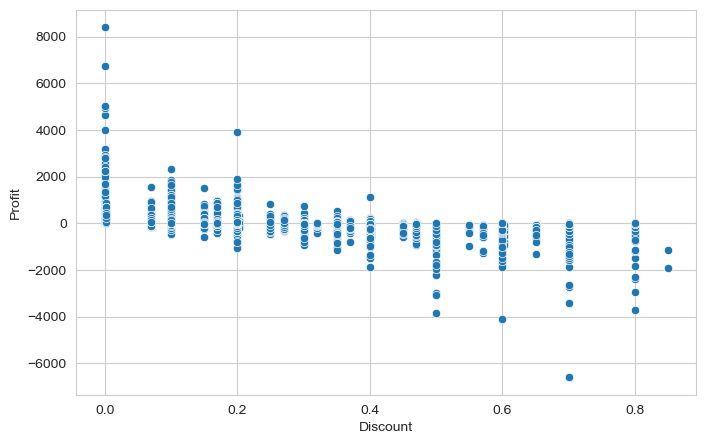

In [52]:
# Profit vs Discount
plt.figure(figsize = (8,5))
sns.scatterplot(x = 'Discount', y = 'Profit', data = df)
plt.show()

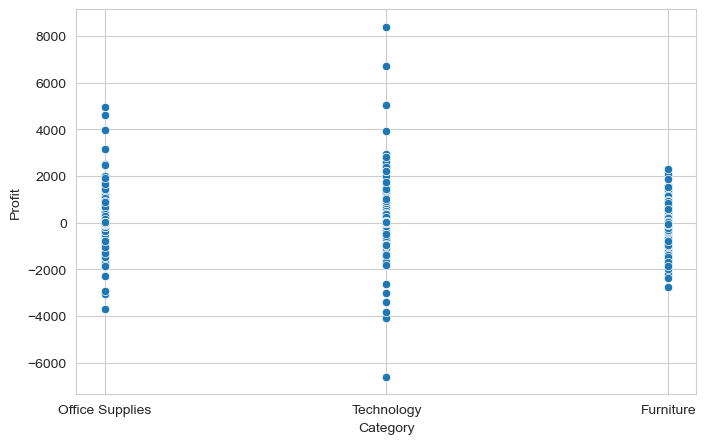

In [53]:
#Profit vs Category
plt.figure(figsize = (8,5))
sns.scatterplot(x = 'Category', y = 'Profit', data = df)
plt.show()

In [54]:
# Q4. iv.  Look for Time Effects Clues. Mention any information you find about the time relationship with any feature.

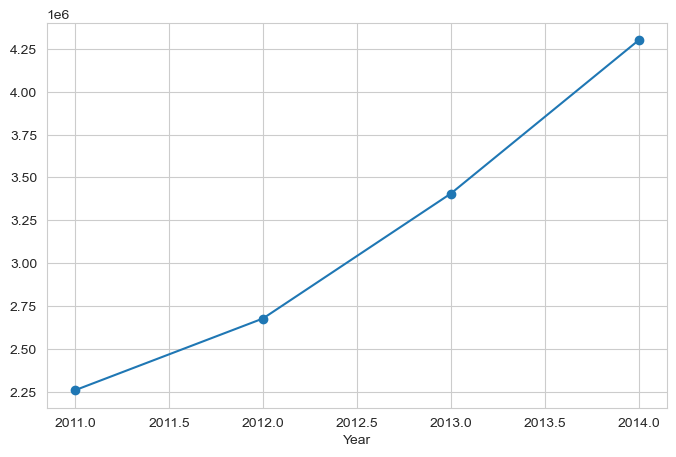

In [55]:
# Sales by Year
year_sales = df.groupby('Year')['Sales'].sum()
year_sales.plot(kind = 'line', marker = 'o', figsize = (8,5))
plt.show()

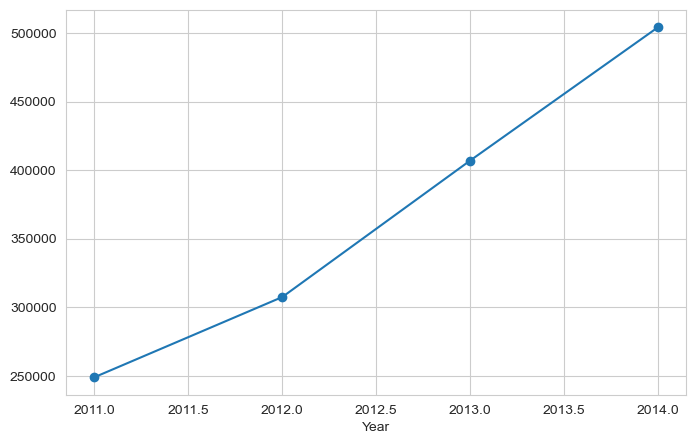

In [56]:
# Profit by Year
year_profit = df.groupby('Year')['Profit'].sum()
year_profit.plot(kind = 'line', marker = 'o', figsize = (8,5))
plt.show()

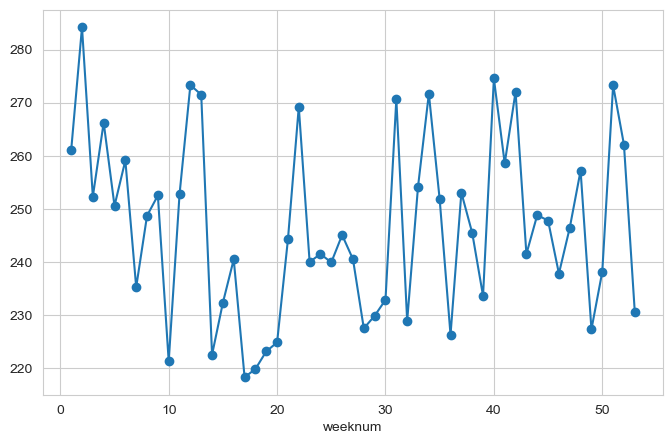

In [58]:
# Sales by Week
weekly_sales = df.groupby('weeknum')['Sales'].mean()
weekly_sales.plot(kind = 'line', marker = 'o', figsize = (8,5))
plt.show()

### Q5. Perform Bi-variant Analysis for categorical to numerical features.

In [59]:
# Q5. i. Profit by Category: Which category has the highest median profit? Which has the lowest? Which category shows the widest spread (largest IQR) in Profit? What does that suggest about profit consistency? 

Median Profit by Category:
Category
Technology         29.9400
Furniture          15.5022
Office Supplies     6.5538
Name: Profit, dtype: float64

IQR of Profit by Category:
Category
Technology         98.350
Furniture          81.535
Office Supplies    20.130
Name: Profit, dtype: float64


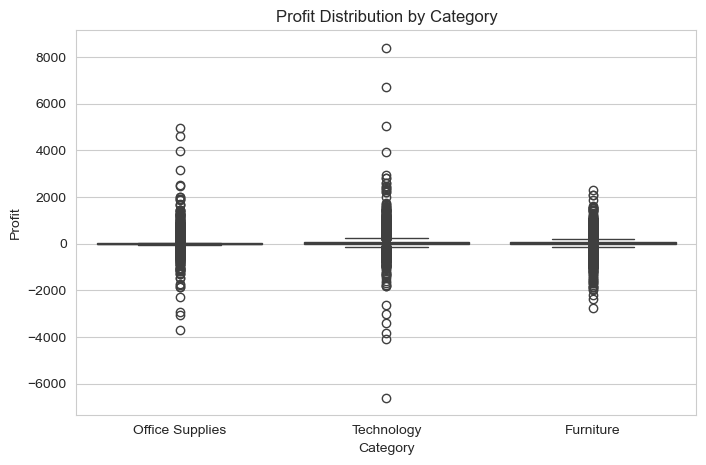

In [87]:
# Median Profit by Category
median_profit = df.groupby('Category')['Profit'].median().sort_values(ascending=False)
print("Median Profit by Category:")
print(median_profit)

# IQR (Interquartile Range) by Category
iqr_profit = df.groupby('Category')['Profit'].agg(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
).sort_values(ascending=False)

print("\nIQR of Profit by Category:")
print(iqr_profit)

plt.figure(figsize = (8,5))
sns.boxplot(x = 'Category', y = 'Profit', data = df)
plt.title('Profit Distribution by Category')
plt.show()

In [65]:
# Q5. ii. Sales by Category: Which category has the highest median sales? Does it also have the highest median profit? 

Median Sales by Category:
Category
Technology         260.0
Furniture          220.0
Office Supplies     46.0
Name: Sales, dtype: float64

Median Profit by Category:
Category
Technology         29.9400
Furniture          15.5022
Office Supplies     6.5538
Name: Profit, dtype: float64


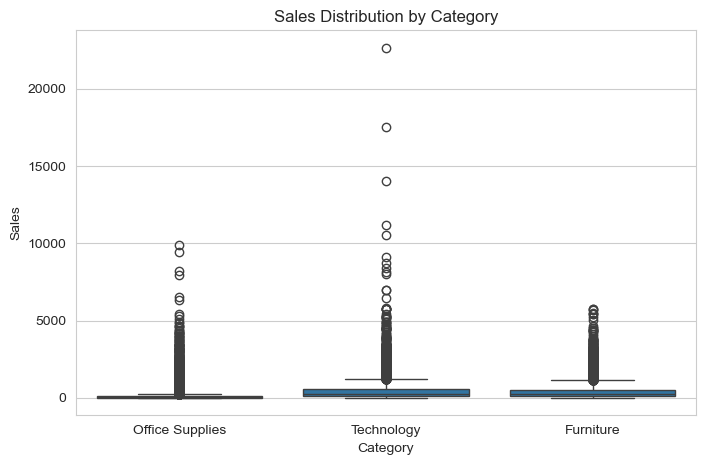

In [88]:
median_sales = df.groupby('Category')['Sales'].median().sort_values(ascending=False)

print("Median Sales by Category:")
print(median_sales)

median_profit = df.groupby('Category')['Profit'].median().sort_values(ascending=False)

print("\nMedian Profit by Category:")
print(median_profit)

# Boxplot for Sales by Category
plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Sales', data=df)
plt.title('Sales Distribution by Category')
plt.show()

In [67]:
# Q5. iii. Profit by Segment: Which segment has the highest median profit? Which segment has the most negative/low profit outliers? 

Median Profit by Segment:
Segment
Home Office    9.3200
Corporate      9.3152
Consumer       9.1800
Name: Profit, dtype: float64

Profit Summary by Segment:
               count       mean         std       min  25%     50%      75%  \
Segment                                                                       
Consumer     26518.0  28.254008  174.006045 -6599.978  0.0  9.1800  36.6525   
Corporate    15429.0  28.596042  177.156362 -4088.376  0.0  9.3152  36.9450   
Home Office   9343.0  29.648847  170.577590 -3399.980  0.0  9.3200  37.0800   

                   max  
Segment                 
Consumer     6719.9808  
Corporate    8399.9760  
Home Office  3919.9888  


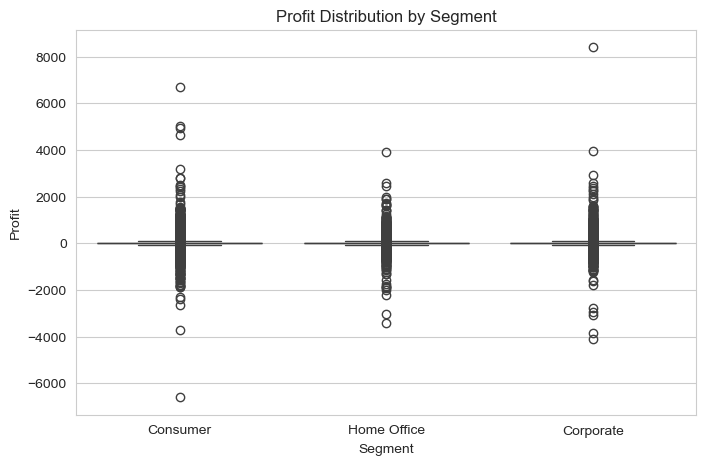

In [89]:
median_profit_segment = (df.groupby('Segment')['Profit'].median().sort_values(ascending=False))

print("Median Profit by Segment:")
print(median_profit_segment)

segment_profit_summary = (df.groupby('Segment')['Profit'].describe())

print("\nProfit Summary by Segment:")
print(segment_profit_summary)

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='Segment', y='Profit', data=df)
plt.title('Profit Distribution by Segment')
plt.show()

In [70]:
# Q5. iv. Sales by Segment: Which segment has the highest median sales? Is the profit pattern consistent with sales? 

Median Sales by Segment:
Segment
Consumer       85.0
Corporate      85.0
Home Office    85.0
Name: Sales, dtype: float64

Median Profit by Segment:
Segment
Home Office    9.3200
Corporate      9.3152
Consumer       9.1800
Name: Profit, dtype: float64


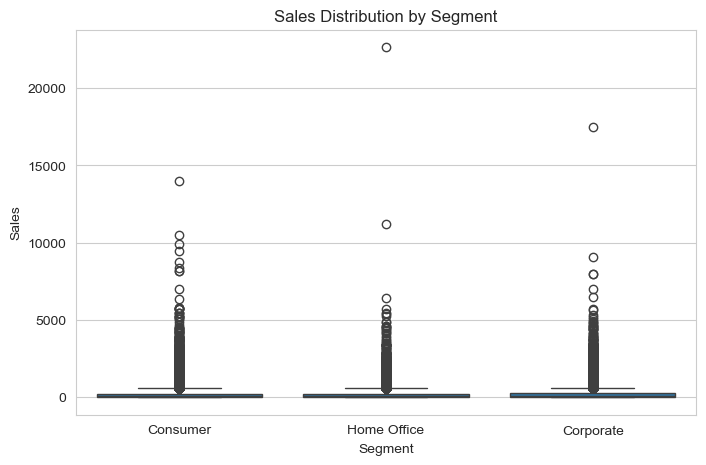

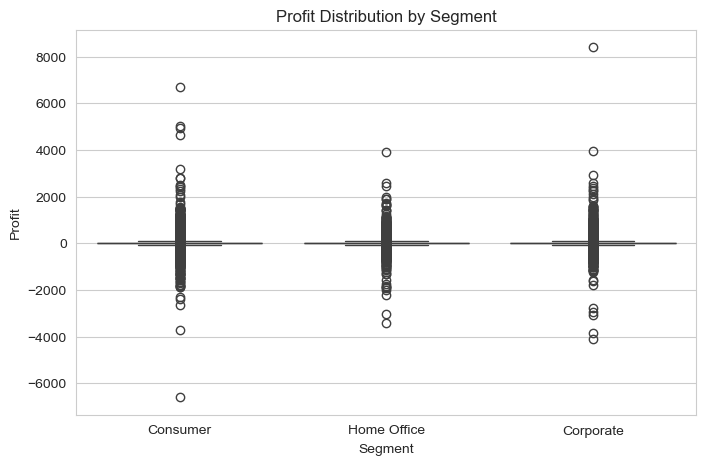

In [90]:
median_sales_segment = (df.groupby('Segment')['Sales'].median().sort_values(ascending=False))

print("Median Sales by Segment:")
print(median_sales_segment)

median_profit_segment = (df.groupby('Segment')['Profit'].median().sort_values(ascending=False))

print("\nMedian Profit by Segment:")
print(median_profit_segment)

plt.figure(figsize=(8,5))
sns.boxplot(x='Segment', y='Sales', data=df)
plt.title('Sales Distribution by Segment')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Segment', y='Profit', data=df)
plt.title('Profit Distribution by Segment')
plt.show()

### Q6. Perform Bivariate Analysis for Market features against Region, Category, and Country.

In [72]:
# Q6. i. Is the Market randomly spread across all Regions? 

Region  Africa  Canada  Caribbean  Central  Central Asia  EMEA  East  North  \
Market                                                                        
APAC         0       0          0        0          2048     0     0      0   
Africa    4587       0          0        0             0     0     0      0   
Canada       0     384          0        0             0     0     0      0   
EMEA         0       0          0        0             0  5029     0      0   
EU           0       0          0     5822             0     0     0   2141   
LATAM        0       0       1690     2972             0     0     0   2644   
US           0       0          0     2323             0     0  2848      0   

Region  North Asia  Oceania  South  Southeast Asia  West  
Market                                                    
APAC          2338     3487      0            3129     0  
Africa           0        0      0               0     0  
Canada           0        0      0               0  

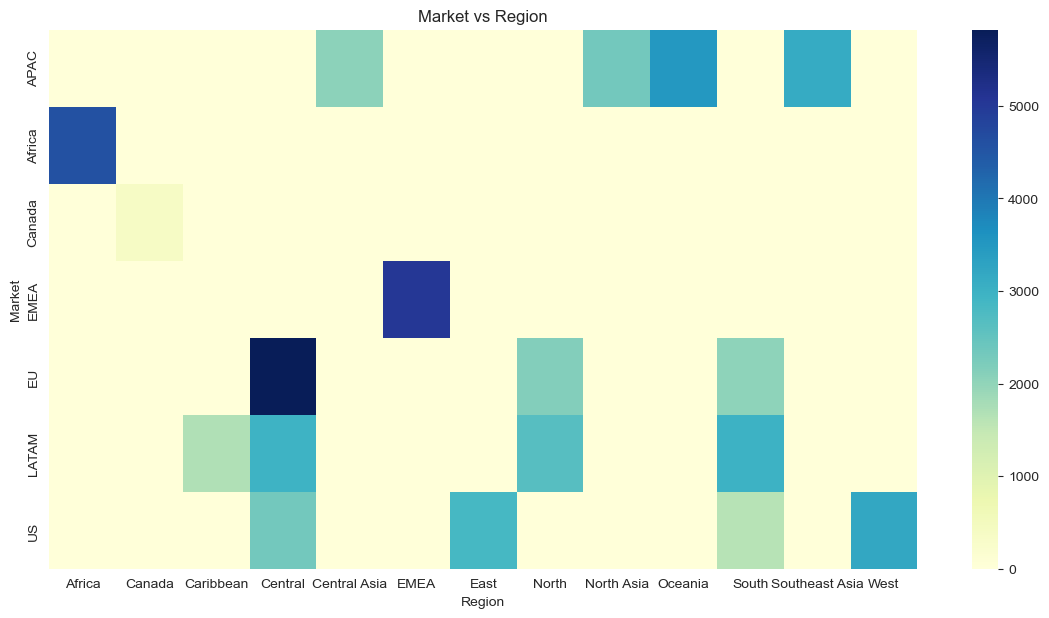

In [92]:
market_region = pd.crosstab(df['Market'], df['Region'])
print(market_region)

plt.figure(figsize = (14,7))
sns.heatmap(market_region, cmap = 'YlGnBu')
plt.title('Market vs Region')
plt.xlabel('Region')
plt.ylabel('Market')
plt.show()

In [74]:
# Q6. ii. Which country has negligible office supply orders? 

In [80]:
all_countries = pd.DataFrame(df['Country'].unique(), columns=['Country'])

office_orders = (df[df['Category'] == 'Office Supplies'].groupby('Country').size().reset_index(name='Office_Supply_Orders'))

country_summary = all_countries.merge(office_orders,on='Country',how='left')

country_summary['Office_Supply_Orders'] = (country_summary['Office_Supply_Orders'].fillna(0).astype(int))

negligible = country_summary[country_summary['Office_Supply_Orders'] <= 5].sort_values('Office_Supply_Orders')

print(negligible)

                      Country  Office_Supply_Orders
115               South Sudan                     0
116                   Burundi                     0
103                   Eritrea                     1
88                    Bahrain                     1
111                   Armenia                     1
109                 Swaziland                     1
114         Equatorial Guinea                     2
112                  Slovenia                     2
40                       Chad                     2
87                    Lesotho                     2
79                 Guadeloupe                     2
146                Tajikistan                     2
99      Republic of the Congo                     3
89                 Montenegro                     3
113                 Macedonia                     3
104                   Lebanon                     4
107                  Paraguay                     4
101                 Sri Lanka                     5
69          

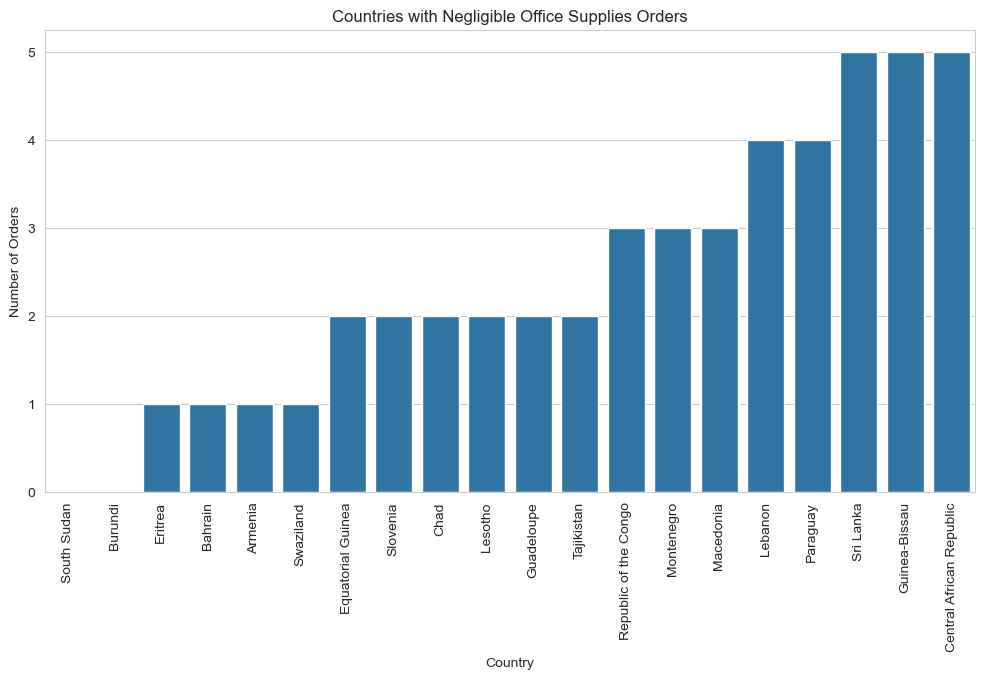

In [82]:
plt.figure(figsize=(12,6))

sns.barplot(data = negligible, x = 'Country', y = 'Office_Supply_Orders')
plt.xticks(rotation = 90)
plt.title('Countries with Negligible Office Supplies Orders')
plt.ylabel('Number of Orders')
plt.show()

In [ ]:
# Q6. iii. What are the most useful insights? 

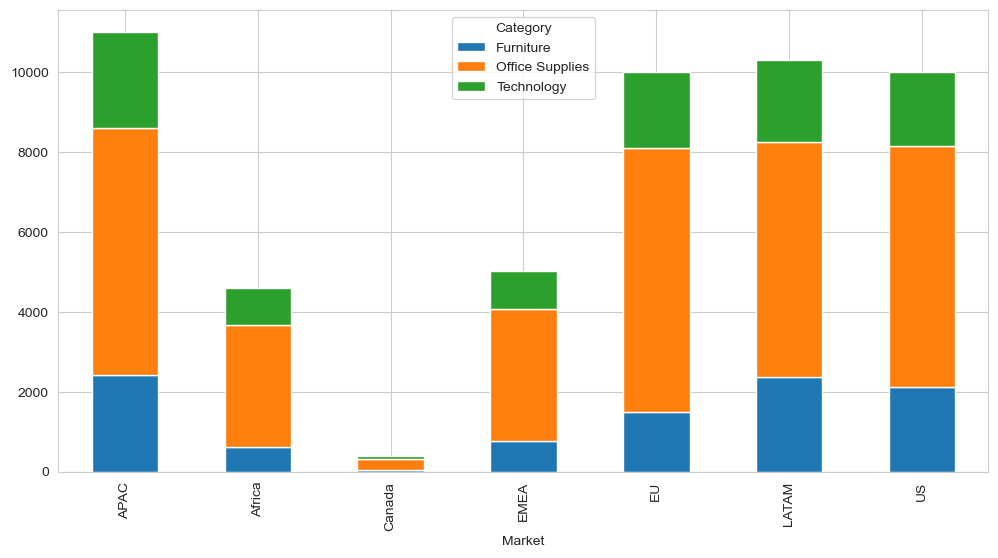

In [83]:
market_cat = pd.crosstab(df['Market'], df['Category'])
market_cat.plot(kind='bar', stacked=True, figsize=(12,6))
plt.show()